# Vector fields & extruded polygons

Two vector visualizations:

- **`vectors`** — arrow glyphs oriented and scaled by a `(u, v, w)` field at a set of points.
- **`extruded_polygons`** — turn polygon footprints into 3-D prisms (height & colour by an attribute), the building-block of extruded-building / choropleth-relief views.

Polygons are read from the GeoDataFrame pyramids hands back (duck-typed — no shapely/geopandas import).

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from pyramids.dataset import Dataset
from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'

def show(scene, title=''):
    """Screenshot a scene off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]          # exclude the bottom colour-bar strip
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} of the scene differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


2026-06-11 21:05:34 | INFO | pyramids.base.config | Logging is configured.


## A 2-D rotational field (w = 0)

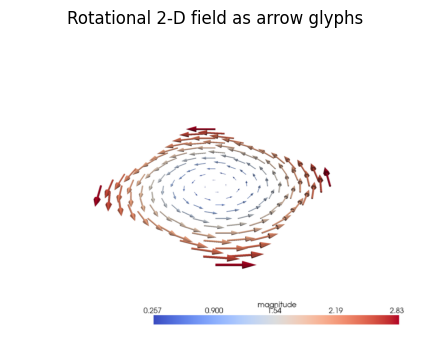

In [2]:
axis = np.linspace(-2, 2, 12)
X, Y = np.meshgrid(axis, axis)
anchors = np.column_stack([X.ravel(), Y.ravel(), np.zeros(X.size)])
field = np.column_stack([-Y.ravel(), X.ravel(), np.zeros(X.size)])     # (u, v, w)
scene = Scene3D(off_screen=True)
scene.vectors(anchors, field, factor=0.3, cmap='coolwarm')
show(scene, 'Rotational 2-D field as arrow glyphs')
scene.close()

## A fully 3-D field (non-zero w)

Arrows tilt out of the plane when the field has a vertical component.

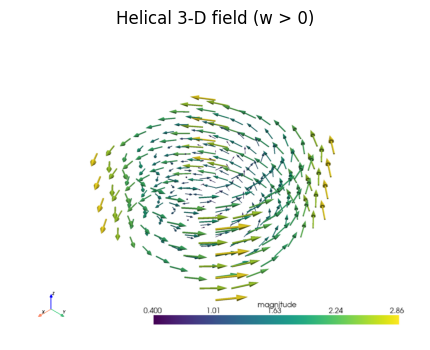

In [3]:
axis = np.linspace(-2, 2, 9)
X, Y, Z = np.meshgrid(axis, axis, np.linspace(0, 2, 4), indexing='ij')
anchors = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
field = np.column_stack([-Y.ravel(), X.ravel(), 0.4 * np.ones(X.size)])  # swirl + steady updraft
scene = Scene3D(off_screen=True)
scene.vectors(anchors, field, factor=0.25, cmap='viridis')
scene.plotter.add_axes()
show(scene, 'Helical 3-D field (w > 0)')
scene.close()

## Extruded polygons

`height` is a constant or a column name; `column` colours the prisms. Scale heights to the footprint so prisms read as blocks, not skinny poles.

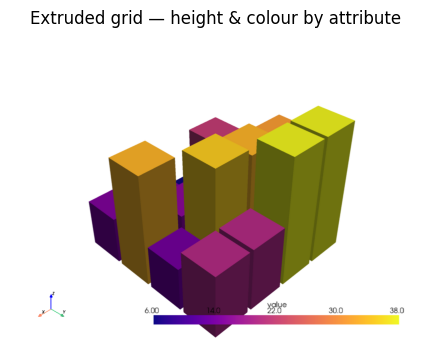

In [4]:
import geopandas as gpd
from shapely.geometry import Polygon
cells = []
vals = []
rng = np.random.default_rng(1)
for i in range(4):
    for j in range(4):
        cells.append(Polygon([(i, j), (i + 0.9, j), (i + 0.9, j + 0.9), (i, j + 0.9)]))
        vals.append(float(rng.integers(5, 40)))
grid = gpd.GeoDataFrame({'pop': vals}, geometry=cells)
grid['height'] = grid['pop'] / 12.0                       # scale to the ~1-unit footprint
scene = Scene3D(off_screen=True)
scene.extruded_polygons(grid, height='height', column='pop', cmap='plasma')
scene.plotter.add_axes()
show(scene, 'Extruded grid — height & colour by attribute')
scene.close()